# Fraud Detection  with Imbalanced Learning Techniques #

## Overview

This project builds a fraud detection model on highly imbalanced transaction data.

The final model achieves:
- Precision: 0.74
- Recall: 0.57
- F1 Score: 0.65
- Alert Rate: 0.6%

This corresponds to ~3 in 4 flagged transactions being genuine fraud, while capturing ~57% of all fraud cases.

The notebook focuses on threshold tuning and operational trade-offs rather than raw model accuracy. The selected threshold prioritises precision to reduce false positives while maintaining acceptable recall, resulting in a low operational alert rate.

## Introduction ##

<a id='cont'></a>
The client, an online gambling platform, requires a predictive model with which to detect customers (players) who use the client’s infrastructure for laundering money through apparent gambling activities.

The main problem is that the data are very unbalanced with 205,637 non-suspect and 1752 suspect players, thus comprising just 0.84% of the sample.

The model is built below, comprising the steps:
 - **[Pre-processing](#PP)**
     - Data cleaning
     - Merging datasets
     
 - **[Exploratory Analysis](#EA)**
     - Interactive histograms of the two classes (suspect & non-suspect players)
     - A/B testing between these  
     
 - **[Machine Learning](#ML)**
      - Balancing the suspect and non-suspect datasets
      - Choice of classifier
      - Visualisation of results
      - Feature importance
  
 - **[Classification Threshold Metrics](#ME)**
      - F1 score
      - Precision
      - Recall
      - Alert Score
    
 - **[Summary](#BM)**   

**Import initial packages**

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

## <a id='PP'>Pre-processing</a> ## 

**Importing the four datasets**

Note that details_fixed.csv is details.csv, fixed via the Emacs editor

In [41]:
df1 = pd.read_csv("details.csv"); #print(df1)
df2 = pd.read_csv("details_fixed.csv"); #print(df2) 

In [42]:
df3 = pd.read_csv("payments.csv"); #print(df3) 
df4 = pd.read_csv("profiling.csv"); # print(df4) 

**Merge by ID**

In [43]:
df23 = df2.merge(df3,on = 'ID')
df234 = df23.merge(df4,on = 'ID'); #print(df234.describe())
print(len(df234['ID'].unique()),len(df234))

207398 207398


One ID per player

**Check for missing values**

In [44]:
def missing(data):
    cols = data.columns 
    for (i,col) in enumerate(cols):
        print("%s (%s)  - missing values = " %(col, type(data[col].iloc[0])), 
              data[col].isnull().sum())
missing(df234)

ID (<class 'numpy.int64'>)  - missing values =  0
Life_Time (<class 'numpy.int64'>)  - missing values =  0
Age (<class 'numpy.int64'>)  - missing values =  0
Is_Retail (<class 'numpy.int64'>)  - missing values =  0
Is_CRM_Email (<class 'numpy.int64'>)  - missing values =  0
CountDeposit (<class 'numpy.int64'>)  - missing values =  0
CountWithdrawal (<class 'numpy.int64'>)  - missing values =  0
TotalDeposits (<class 'numpy.int64'>)  - missing values =  0
TotalWithdrawal (<class 'numpy.int64'>)  - missing values =  0
CountPaymentMethod (<class 'numpy.int64'>)  - missing values =  0
DifferentMethodWithdrawals (<class 'numpy.float64'>)  - missing values =  0
Multi_Device (<class 'numpy.int64'>)  - missing values =  0
IP_Counts (<class 'numpy.int64'>)  - missing values =  0
e_11234 (<class 'numpy.float64'>)  - missing values =  0
e_23456 (<class 'numpy.float64'>)  - missing values =  0
e_34454 (<class 'numpy.float64'>)  - missing values =  0
e_43568 (<class 'numpy.float64'>)  - missing val

No missing values and all features are numeric

**Add in the suspect player data**

In [45]:
df5 = pd.read_csv("suspect.csv"); #print(df5); df5.describe()

These all have Target_ml = 1

**Check if these are in the current dataset**

In [46]:
df234.loc[df234['ID'] == 100095464]

,ID,Life_Time,Age,Is_Retail,Is_CRM_Email,CountDeposit,CountWithdrawal,TotalDeposits,TotalWithdrawal,CountPaymentMethod,DifferentMethodWithdrawals,Multi_Device,IP_Counts,e_11234,e_23456,e_34454,e_43568,e_64645
26,100095464,9,55,0,0,222,38,5640,5200,4,5200.0,0,2,777.65,7381.43,648.52,111.7,2.54


Looks like they are. Could check each one, but this'll come out in the following merge

In [47]:
len(df234)

207398

**Merge the dataset and add a flag for suspected fraud**

Since the suspects have Target_ml = 1, we will flag the non-supects as Target_ml = 0

In [48]:
df2345 = pd.merge(df234, df5, how='outer', on='ID'); #print(df2345)

In [49]:
df2345['Target_ml'] = df2345['Target_ml'].replace(np.nan, 0)
df2345['Target_ml'] = df2345['Target_ml'].astype(int)
#print(df2345); 
#df2345['Target_ml'].describe()

Check the numbers 

In [50]:
non = df2345[df2345['Target_ml'] == 0]
sus = df2345[df2345['Target_ml'] == 1]
print('Total length of dataset = %d, of which %d are suspect and  %d are not' 
      %(len(df2345), len(sus),len(non)))

Total length of dataset = 207398, of which 1752 are suspect and  205646 are not


Numbers add up.

[Back to contents](#cont)

## <a id='EA'>Exploratory Analysis</a> ##

**Dictionary describing the features**

Will be called later

In [51]:
feat_dict={"ID":"the unique ID of the player",
    "Life_Time":"how many years the player has been a client", 
    "Age":"the client's age in years",
    "Is_Retail":"whether the player is also a retailer",
    "Is_CRM_Email":"whether the player has been contacted by us by the Customer Relationship Management team",
    "CountDeposit":"number of deposits",
    "CountWithdrawal":"number of withdrawals",
    "TotalDeposits":"value of deposits",
    "TotalWithdrawal":"value of withdrawals",
    "CountPaymentMethod":"number of different deposit/withdrawal methods", 
    "DifferentMethodWithdrawals":"value of different deposit/withdrawal methods",
    "Multi_Device":"0 flags < 3 devices and 1 flags >= 3 devices used for payment",
    "IP_Counts":"number of different IP addresses used for transactions",
    "e_11234":"aggregated variable describing the players' activity",
    "e_23456":"aggregated variable describing the players' activity",
    "e_34454":"aggregated variable describing the players' activity",
    "e_43568":"aggregated variable describing the players' activity",
    "e_64645":"aggregated variable describing the players' activity"
          }

**Histogram function so each feature can be examined in turn**

In [52]:
def hist(para,dbs,con): # dataframe, parameter of interest and desired bin width
    data = df2345[para]
    #print(df2345[para].describe())
    
    min_val = np.min(data); max_val = np.max(data)
    dbw = (max_val - min_val)/dbs
    min_boundary = -1.0 * (min_val % dbw - min_val)
    max_boundary = max_val - max_val % dbw + dbw
    n_bins = int((max_boundary - min_boundary) / dbw) + 1
    bins = np.linspace(min_boundary, max_boundary, n_bins)
    
    ## Setting up the plot
    font = 14
    plt.rcParams.update({'font.size': font})
    plt.figure(figsize=(6,4))
    ax = plt.gca()
    plt.setp(ax.spines.values(),linewidth=2)
    ax.tick_params(direction='in', pad = 7,length=6, width=1.5, which='major',right=True,top=True)
    ax.tick_params(direction='in', pad = 7,length=3, width=1.5, which='minor',right=True,top=True)
   
    ## Histograms
    m1= np.mean(non[para]); s1 = np.std(non[para],ddof=1)
    label = "Non-suspect: $\mu = %1.2f, \sigma = %1.2f$" %(m1,s1)
    ax.hist(non[para], bins=bins, color="w", edgecolor='grey', 
            lw=2, label = label)     
                         
    m2 = np.mean(sus[para]); s2= np.std(sus[para],ddof=1)
    label = "Suspect:         $\mu = %1.2f, \sigma = %1.2f$" %(m2,s2)
    ax.hist(sus[para], bins=bins, color="r", edgecolor='k', 
            lw=2, label = label);
    text = '%s' %(para)                   
    plt.ylabel('Number', size=14); plt.xlabel(text, size=font)    
     
    # Need a log y-scale due to differences in sample sizes 
    ax.set_yscale('symlog');
    def update_ticks(z, pos):
        if z ==0:
            return '0'
        elif z >=1 and z <1000:
            return '%d' %(z)
        elif z < 1 and z > 0.001:
            return z
        else:
            return  '10$^{%1.0f}$' %(np.log10(z))
    
    # Fix tick spacing       
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(update_ticks))
    x_maj = ax.get_xticks()
    x_min = (x_maj[1] -  x_maj[0])/5
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(x_min))
    ymin, ymax = plt.ylim(); 
    ax.set_ylim([ymin,1.2*ymax])
    ax.legend(fontsize = 0.7*font,loc="best")
    plt.show(); plt.close()
    ### A/B testing between the two classes
    from scipy.stats import norm
    #con = 95
    p = 0.5*(1-con/100) # 2-sided
    alpha = 0.5-p
    m = np.abs(m1 - m2)
    n1 = len(non); n2 = len(sus)
    
    pooled_var = s1**2/n1 + s2**2/n2
    pooled_SD = pooled_var**0.5
    pooled_SE = pooled_SD*(1/n1 + 1/n2)**0.5
    Z = norm.ppf(1-p,loc=0,scale=1)
    CI = Z*pooled_SD
    
    desc = feat_dict.get(para) # Description from feat_dict
    print("For %s: %s" %(para,desc))
    
    print("\nAt %1.1f%% confidence the difference in the sample means is %1.2f +/- %1.2f" %(con,m,CI))
    if (m-CI < 0) & (m+CI >0):
        sig = 'passes through 0, so not statistically significant'
    else:
        sig = "doesn't passes through 0, so statistically significant"
    print("(%1.2f to %1.2f) - %s" %(m-CI,m+CI, sig))  

**Select the parameter of interest, binning for histogram and confidence interval with which to test the population means of the suspect and non-suspect players**

In [53]:
# Dropdowns
import ipywidgets as widgets
from IPython.display import display
plt.ioff()

options = df234.columns
options = options[1:]; #print(options)
dd_para = widgets.Dropdown(options= options,value='Life_Time',
                            description='Select parameter:',
                            style={'description_width': 'initial'},
                            layout={'width': '40%'}, disabled=False)

dd_dbs = widgets.Dropdown(options= [2,5,10,20,50,100],value=10,
                            description='No. of bins:',
                            layout={'width': '20%'},  disabled=False)

dd_con = widgets.Dropdown(options= [80,90,95,97.5,99,99.9,99.99],value=95,
                            description='Confidence level [%]:',
                            style={'description_width': 'initial'},
                            layout={'width': '30%'},  disabled=False)

out = widgets.interactive_output(hist, {'para':dd_para, 'dbs':dd_dbs, 'con':dd_con})

ui = widgets.HBox([dd_para,dd_dbs,dd_con]) # using HBox/VBox makes it look cleaner
display(ui, out)

Output()

Note: The ordinate is shown on a log-scale as the suspect sample is only 0.84% of the total

Note that the eldest suspect age is 89, above which there 63 non-suspect players (going all the way up to 120 years old)

Where this makes sense to use (the non-binary parameters), A/B testing shows that there is a significant difference in most of the means. Both samples are much larger than 30, so did not need to use the t-distribution (see https://github.com/steviecurran/two-sample)

[Back to contents](#cont)

## <a id='ML'>Machine Learning </a> ##

**Splitting the data into training and test sets**

In [54]:
cols = df2345.columns;  #print(cols)
rem = cols.drop("ID"); #print(rem)
df = df2345[rem]; #print(df)
target = 'Target_ml'
test_frac = 0.2

X = df.drop(columns=target)
y = df[target]

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
                                                stratify=y, # preserves the fraud ratio
                                                random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

N = [x for x in y_train if x==0]; S = [x for x in y_train if x==1]
print('Training data have %d suspect and %d non-suspect players' %(len(N),len(S)))
N = [x for x in y_test if x==0]; S = [x for x in y_test if x==1]
print('Test data have %d suspect and %d non-suspect players' %(len(N),len(S)))

Training data have 164516 suspect and 1402 non-suspect players
Test data have 41130 suspect and 350 non-suspect players


**Balancing the suspect and non-suspect datasets**

There are only 1752 suspect players and so from raw statistics alone we can ascertain that
there is a probability of 100 × 1752/207389 = 0.84% of the player being suspect. 
This will give an accuracy of 99.16% based upon the probability alone, but will be of little use in predicting which are the fraudulent players. The data must therefore be balanced, which can be done via

- *undersampling*: which randomly selects the number of instances in the minority set from the majority set

- *oversampling*: via SMOTE (*Synthetic Minority Over-sampling Technique*), which synthesises new data 

- *class weighting*: which weighs the class inversely by how often it appears in the data

These are applied only to the training data to avoid data leakage and ensure realistic evaluation.

Given the class imbalance, we expect a compromise between the precision (true positives/predicted positives)  and recall (true positives/actual positives), with recall typically being prioritised in rare event detection. The cost of this is an increase in the number of false alarms, but it is more likely to flag fraudulent activities. Generally, recall is prioritised when false negatives are expensive (or dangerous) and precision when false positives are to be minimised.

**Class imbalance, machine learning and plotting functions**

Here we:

- Define the machine learning classifiers we wish to test

- Include an option to resample the data to address the class imbalance, via oversampling, undersampling or class weighting. *All resampling was applied only to the training set, with evaluation performed on an untouched test set*

- Give a choice of threshold above which to convert probabilities to class predictions

- Give the option to tune the threshold by running models in 0.01 increments

- Visualise the results:

    - The normalised confusion matrix
    
    - A precision-recall plot
    
    - A *receiver operating characteristic* (ROC) curve. This shows the trade-off between detecting fraud and incorrectly flagging legitimate transactions across different classification thresholds.
    
    - A diagnostic plot which shows the mean predicted fraud probability for both the suspect and non-suspect players, with adjustable confidence intervals
    
 - The feature importance 

A rather long cell, but separating these loses a lot of the interactive functionality

In [60]:
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score,recall_score,f1_score,confusion_matrix
from sklearn.metrics import precision_recall_curve,ConfusionMatrixDisplay,roc_curve,auc
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

classifiers = {
    "Decision Tree": DecisionTreeClassifier(max_depth = 5),
     #"Gradient Boost": GradientBoostingClassifier(max_depth=5,n_estimators=50,random_state=42),
    "Logistic Regression": LogisticRegression(C=0.08858667, solver='newton-cg'),
     #"k-Nearest Neighbours": KNeighborsClassifier(n_neighbors=6),  
     # COMMENTED DON'T WORK WITH Class Weighting
     #"Random Forest": RandomForestClassifier(min_samples_split=5, n_estimators=200,random_state=42),
      # TAKES TOO LONG
    "Support Vector": SVC(C=1, gamma=0.1,probability=True), 
    'XGBoost': XGBClassifier(n_estimators=500,max_depth=5,learning_rate=0.03,
                             subsample=0.8,colsample_bytree=0.8,random_state=42)
    }

def resamp(cl,desc,th1,th2,con,feat,tun):  
    threshold = th1 + float(th2)/100
    classifier = classifiers.get(cl) 
    if desc != "Class Weighting":
        classifier.set_params(class_weight=None)
        if desc == 'SMOTE':
            sampler = SMOTE()
        else:
            sampler = RandomUnderSampler(sampling_strategy='majority') 
        model = Pipeline([(desc,sampler),(cl, classifier)])
    else:
        if cl != 'XGBoost':
            classifier.set_params(class_weight='balanced')
        else:
            ratio = float(np.sum(y_train == 0) / np.sum(y_train == 1))
            classifier.set_params(scale_pos_weight=ratio) 
            #print('****blah****', classifier)
        desc = "class"
        model = classifier
    model.fit(X_train, y_train)
    
    y_prob = model.predict_proba(X_test)[:,1] 
    #the model’s estimated probability that a transaction is fraud
    if tun != 'No':
        f1_scores = []
        all_scores = []
        thresholds = np.linspace(0.01,0.99,99) # FINE TUNING
        for t in thresholds:
            y_pred = (y_prob > t).astype(int)
            f1_scores.append(f1_score(y_test, y_pred))
            all_scores.append(t)
            all_scores.append(f1_score(y_test, y_pred))
            all_scores.append(precision_score(y_test, y_pred))
            all_scores.append(recall_score(y_test, y_pred))
            alerts = y_pred.sum()
            all_scores.append(alerts/len(y_pred))
            
            #y_pred = (y_prob > threshold).astype(int)
        best = thresholds[np.argmax(f1_scores)]
        all_scores = np.reshape(all_scores,(-1,5));
        th_df = pd.DataFrame(all_scores, columns=['threshold','f-score','precision','recall','alert']);
        th_df.to_csv('thresholds.csv')
        print('================= TRESHOLD TUNING ===================================')
        print("For %s with %s imbalance correction, highest F1 (= %1.3f) at threshold = %1.3f" 
              %(cl,desc,np.max(f1_scores),best))
        print('Data written to thresholds.csv')
        print("======================================================================")
    
    y_pred = (y_prob > threshold).astype(int)
    #the final classification decision after applying a threshold
    y_score = classifier.predict_proba(X_test)[:, 1]
    #return cl,desc,threshold,y_test,y_pred,y_prob,y_score
    
    ## PUTTING METRIC CODE HERE - MAKES THIS CELL VERY LONG, BUT LOSE INTERACTIVITY OTHERWISE
    from sklearn.metrics import precision_recall_curve,ConfusionMatrixDisplay,roc_curve, auc
    #Evaluate Performance
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    print("For %s resampled via %s with classification threshold = %1.2f" %(cl,desc, threshold))
    print("---------------------------------------------------------------------")
    print("Precision = %1.3f" %(precision)); print("Recall  = %1.3f" %(recall))
    print("F1 score = %1.3f" %(f1))
    total = tp + fp + tn + fn
    print('\nNo. true positives (TP)  = %d (%1.2f%%)' %(tp,100*tp/total))
    print('No. false positives (FP)  = %d (%1.2f%%)' %(fp,100*fp/total))
    print('No. true negatives (TN)  = %d (%1.2f%%)' %(tn,100*tn/total))
    print('No. false negatives (FN) = %d (%1.2f%%)' %(fn,100*fn/total))
    print('The confusion matrix below shows the normalised values')

    precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
    
    font = 12
    plt.rcParams.update({'font.size': font})

    figsize = 12,10; gridsize = 20,20
    fig = plt.figure(figsize=(figsize))
    
    ax1 = plt.subplot2grid((gridsize), (0, 0), colspan=8, rowspan = 8)
    ax2 = plt.subplot2grid((gridsize), (0, 9), colspan=8, rowspan = 6)
    ax3 = plt.subplot2grid((gridsize), (8, 9), colspan=8, rowspan = 6)
    ax4 = plt.subplot2grid((gridsize), (10 ,1), colspan=6, rowspan = 4)
    
    disp = ConfusionMatrixDisplay.from_predictions(y_test,y_pred,
                                                   normalize="true",
                                                   ax=ax1,cmap=plt.cm.Blues,
                                                   display_labels=['Non-suspect', 'Suspect'], 
                                                   colorbar=False)

    ax1.tick_params(axis='both', which='major', labelsize=font,pad=10) 
    plt.setp(ax1.get_yticklabels(), rotation=90, ha='center')

    for labels in disp.text_.ravel(): # FOR NUMBERS IN BOXES
        labels.set_fontsize(font)
        labels.set_text(f"{float(labels.get_text()):.4f}")

    ax1.set_xlabel('CM predicted',fontsize=font, labelpad=10)
    ax1.set_ylabel('CM actual',fontsize=font, labelpad=10)
    ax1.set_title("%s validation" %(cl), fontsize=font)

    # PRECISION-RECALL CURVE
    ax2.plot(recall_vals, precision_vals, lw =3, color = 'r', 
             label = '%s precision-recall curve' %(cl))
    ax2.plot([0, 1], [1, 1], linestyle='--', color='k', lw=2,
             label='Ideal Classifier (Precision=1.0)')
    plt.setp(ax2.spines.values(),linewidth=2)
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.legend(fontsize = 0.8*font,loc='best',labelcolor='k')

    ## ROC CURVE
    tr = 0.5
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr) # TPR (True Positive Rate) → y-axis  FPR (False Positive Rate) → x-axis

    plt.setp(ax3.spines.values(),linewidth=2)
    ax3.plot(fpr, tpr, linestyle = '-',  lw =3, color = 'r', zorder =2, label="ROC: AUC = %1.2f" %(roc_auc))
    ax3.plot(fpr, fpr, linestyle = '--',  lw =2, color = 'k', zorder = 2,label="%1.1f benchmark" %(tr))
    ax3.fill_between(fpr, y1 = 0, y2 = tpr, where= (fpr > 0) & (fpr < tpr),color= "lightgray",zorder=1)
    ax3.set_xlabel('False positive rate'); ax3.set_ylabel('True positive rate')
    ax3.legend(fontsize = 0.8*font,loc='best')

    ## Diagnostic Plot - ERROR BARS BETTER
    plt.setp(ax4.spines.values(),linewidth=2)
    sus_probs = y_prob[y_test == 1]
    non_probs = y_prob[y_test == 0]

    from scipy.stats import norm
    #con = 99
    p = 1-con/100
    alpha = 0.5-p/2

    def stats(data):
        m = np.mean(data)
        n = len(data)
        s = np.std(data,ddof=1)
        Z = norm.ppf(1-p,loc=0,scale=1)
        SE = s/(float(n)**0.5)
        CI = Z*SE

        return m,n,Z,s,CI

    y_numeric = [0.3, 0.7]
    y_words = ['Suspect', 'Non-suspect']
    
    m,n,Z,s,CI = stats(sus_probs)
    print("\nSus: %1.2f%% confidence,the mean is %1.2f +/- %1.2f (range of %1.2f to %1.2f)"
              %(con,m,CI,m-CI,m+CI))

    ax4.errorbar(m,y_numeric[0], xerr=CI, fmt='o', color='r', capsize=5, label= "$%1.3f\pm%1.3g$" %(m,CI))

    m,n,Z,s,CI = stats(non_probs)
    print("Non: %1.2f%% confidence, the mean is %1.2g +/- %1.2g (range of %1.2g to %1.2g)"
              %(con,Z,CI,m-CI,m+CI))

    ax4.errorbar(m, y_numeric[1], xerr=CI, fmt='o', color='g', capsize=5, label= "$%1.3f\pm%1.3g$" %(m,CI))

    ax4.set_ylim(0,1)
    ax4.set_xlabel("Predicted laundering probability (%1.2f%% confidence)" %(con));
    plt.yticks(y_numeric, y_words)
    ax4.legend(fontsize = 0.8*font,loc='best')
    #plt.tight_layout()
    plt.show()
    
    ###### FEATURE IMPORTANCE ####
    if feat != 'No (as can take a while)':
        print("\nMay take a few minutes to show feature importance")
        from sklearn.inspection import permutation_importance
        results = permutation_importance(model, X_train, y_train, scoring='accuracy')
        importance = results.importances_mean
        features = df.drop(target,axis = 1) 
        features = features.columns.tolist()
        df1 = pd.DataFrame(features, columns=['Feature']); 
        df2 = pd.DataFrame(importance, columns=['Importance'])
        df1['Importance'] = df2.Importance  # adding to df1
        #print(df1.sort_values(by=['Importance'], ascending=False)) 
        if feat == 'Alphabetically':
            tmp = df1.sort_values(by=['Feature'], ascending=False)
        else:    
            tmp = df1.sort_values(by=['Importance'], ascending=True)

        #font = 12
        #plt.rcParams.update({'font.size': font})
        plt.figure(figsize=(6,5))
        ax = plt.gca()
        plt.barh(tmp['Feature'],tmp['Importance'],fc="silver", ec='b', label=dd_samp.value)
        plt.title('%s Feature Importance' %(dd_ML.value),fontsize=font)
        plt.legend(fontsize = 0.8*font,loc='best')    
        plt.show()

In [61]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
 
options = classifiers.keys()
dd_ML = widgets.Dropdown(options=options, value='XGBoost', 
                         description='Classifier:',
                            style={'description_width': 'initial'},
                            layout={'width': '40%'}, disabled=False)

dd_samp = widgets.Dropdown(options=['Under Sampling','Class Weighting','SMOTE'],
                            value='Class Weighting', 
                            description='Class balance method:',
                            style={'description_width': 'initial'},
                            layout={'width': '40%'}, disabled=False)

options = np.linspace(0.1,0.9,9); #print(options)
dd_th = widgets.Dropdown(options= options, value=0.9, 
                        description='Calibration threshold',
                        style={'description_width': 'initial'},
                        layout={'width': '25%'}, disabled=False)

options = np.linspace(0,9,10); 
dd_thp = widgets.Dropdown(options= options, value=0, 
                        description='2nd decimal place',
                        style={'description_width': 'initial'},
                        layout={'width': '25%'}, disabled=False)

dd_con = widgets.Dropdown(options= [90,95,99,99.9,99.99], value=95, 
                        description='Confidence level',
                        style={'description_width': 'initial'},
                        layout={'width': '25%'}, disabled=False)

dd_fi = widgets.Dropdown(options= ['No (as can take a while)','Alphabetically','By importance'], 
                        value= 'No (as can take a while)', 
                        description='Show feature importance',
                        style={'description_width': 'initial'},
                        layout={'width': '45%'}, disabled=False)

dd_tun = widgets.Dropdown(options= ['No','Yes (could take a while)'], 
                        value= 'No', 
                        description='Write new data for theshold tuning plot: ',
                        style={'description_width': 'initial'},
                        layout={'width': '45%'}, disabled=False)


out = widgets.interactive_output(resamp,{'cl':dd_ML,'desc':dd_samp,
                                         'th1':dd_th,'th2':dd_thp,
                                         'con':dd_con, 'feat':dd_fi,
                                          'tun':dd_tun})
ui = widgets.HBox([dd_ML,dd_samp])
ui2 = widgets.HBox([dd_th,dd_thp, dd_con])
ui3 = widgets.HBox([dd_fi,dd_tun])
display(ui,ui2,ui3,out)

Output()

[Back to contents](#cont)

## <a id='ME'>Classification Threshold Metrics</a> ##

Plotting the F1 score, precision, recall and alert score using the data generated via the
*write new data for threshold tuning plot* widget, above

The highest F1 score (0.646) occurs at a threshold of 0.910
Here the precision = 0.743, recall = 0.571 and alert score = 0.006


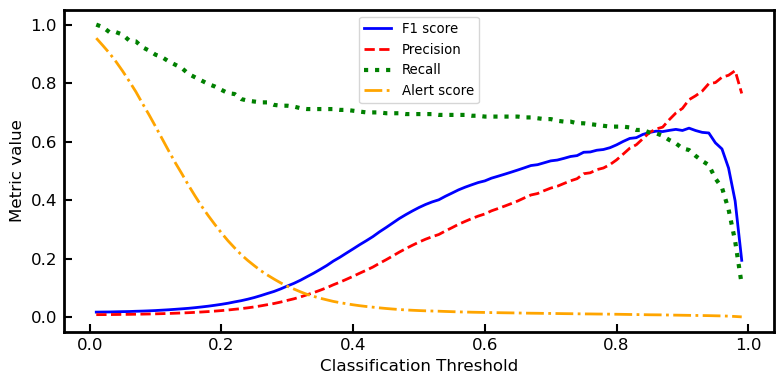

In [38]:
df = pd.read_csv("thresholds.csv"); #print(df)

f = df['f-score']; maxF1 = max(f)
t = df['threshold']; maxt = t[f.argmax()]
p = df['precision']; maxp = p[f.argmax()]
r = df['recall']; maxr = r[f.argmax()]
a = df['alert']; maxa = a[f.argmax()]

font = 12
plt.rcParams.update({'font.size': font})
fig, ax = plt.subplots(figsize = (8, 4))
plt.setp(ax.spines.values(),linewidth=2)
plt.plot(df['threshold'], df['f-score'], lw =2, color = 'b', label = "F1 score")
plt.plot(df['threshold'], df['precision'], lw =2, ls = '--', color = 'r', label = "Precision")
plt.plot(df['threshold'], df['recall'], lw =3, ls = 'dotted',color = 'g', label = "Recall")
plt.plot(df['threshold'], df['alert'], lw =2, ls = 'dashdot',color = 'orange', label = "Alert score")
plt.xlabel("Classification Threshold"); plt.ylabel("Metric value")
ax.legend(fontsize = 0.8*font,loc='best')
ax.tick_params(direction='in', pad = 5,length=6, width=1.5, which='major')
ax.tick_params(direction='in', pad = 5,length=3, width=1.5, which='minor')
#plt.title("XGBoost - Classification Threshold Tuning", fontsize = font)
plt.tight_layout()
print('The highest F1 score (%1.3f) occurs at a threshold of %1.3f' %(maxF1,maxt))
print('Here the precision = %1.3f, recall = %1.3f and alert score = %1.3f' %(maxp,maxr,maxa))


## <a id='BM'>Summary</a> ##

Several models were evaluated, with some of the baseline models (e.g. the *Decision Tree Classifier* with a classification threshold of 0.5), giving precisions as low at 0.06, although high recall values (0.70, giving F1 = 0.11). This indicates that the majority of flagged transactions are false positives and investigating these would generate an unsustainable workload.

The *XGBoost* classifier with class weighting achieved the best balance of precision and recall. The optimal classification  threshold (0.91) was selected to maximise F1 score while maintaining a low alert rate, giving:

 - True positives (TP)  = 200 (0.482%)
 - False positives (FP)  = 69 (0.166%)
 - True negatives (TN)  = 41061 (98.990%)
 - False negatives (FN) = 150 (0.362%)
 
Due to extreme class imbalance, the normalized confusion matrix shows near-perfect true negatives. This reflects the dominance of the majority class rather than perfect model performance.

From the confusion matrix:

 - There are 269 players flagged as suspect, of which 200 actually are. This gives a precision of $\frac{TP}{TP+FP}= 74$%,  which is a balanced performance for an imbalanced dataset.

 - The recall $\frac{TP}{TP+FN}= 57$%, means that the majority of alerts correspond to genuine fraud cases.

- While the high classification threshold (0.91) maximises $F1 = \frac{2TP}{2TP + FP + FN} = 0.65$, it ensures that the alert rate, $\frac{TP + FP}{TP + FP + TN + FN} = 0.6$% low.

In conclusion, increasing the threshold substantially reduces the number of false positives, improving operational efficiency. However, this also decreases recall, illustrating the fundamental trade-off in rare-event detection between catching fraudulent activity and limiting investigation workload.

PIt should be noted that the performance may be sensitive to class imbalance assumptions and could benefit from cost-sensitive learning or further feature engineering.

[Back to contents](#cont)